# Batch & Pairing

<!-- markdownlint-disable MD033-->
<div class="page-subtitle">
Scaling training-data creation from one image to many paired files
</div>
<!-- markdownlint-enable MD033 -->

---

## 1. Motivation

Real project data rarely comes as a single tidy image and a single annotation file. You will often have several scenes, tiles, or dates, each needing the same tiling treatment, and each needing to be paired correctly with its own annotations. Getting the pairing wrong, silently, is one of the more damaging mistakes you can make at this stage, since a model trained on mismatched images and masks can still appear to train "successfully" while learning nothing useful.

---

## 2. Core idea

`export_geotiff_tiles_batch()` extends single-image tiling to a folder of images, and supports three ways of matching images to their {term}`annotations <Annotation>`, depending on how your files happen to be organized.

---

## 3. Workflow

### A. Know your three pairing options

- **Single vector file covering all images**: most efficient when one annotation file spans several image tiles.
- **Multiple vector files matched by sorted order**: pairs the first image with the first mask file, the second with the second, and so on. Use this only when you are confident the sorted file lists genuinely line up.
- **Multiple vector files matched by filename**: pairs files that share the same base name (for example, `tile1.tif` with `tile1.geojson`). This is the safest option whenever your naming convention supports it.

| Mode | Use when | Key parameter |
| --- | --- | --- |
| Single vector file | One annotation file covers all images. | `masks_file="path/to/file.geojson"` |
| Multiple files by sorted order | Files line up alphabetically. | `masks_folder="path/"`, `match_by_name=False` |
| Multiple files by filename | Images and labels share base names. | `masks_folder="path/"`, `match_by_name=True` |

Matching by filename is usually the safest option when filenames are designed consistently.

### B. Get and explore the sample data

The sample dataset for this page contains two NAIP image tiles, plus building annotations in two formats: one GeoJSON file covering both tiles, and separate GeoJSON files matched to each tile. Downloading and listing it first shows you exactly what the three pairing modes below are actually operating on.

In [1]:
import os
import geoai
from pathlib import Path

DATA_DIR = Path("data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

url = "https://data.source.coop/opengeos/geoai/naip-rgb-train-tiles.zip"
data_dir = geoai.download_file(url, output_path=str(DATA_DIR / Path(url).name))

print("Images:")
for f in sorted(os.listdir(f"{data_dir}/images")):
    print(f" - {f}")

print("\nAnnotations (single file):")
for f in sorted(os.listdir(f"{data_dir}/masks1")):
    print(f" - {f}")

print("\nAnnotations (multiple files):")
for f in sorted(os.listdir(f"{data_dir}/masks2")):
    print(f" - {f}")

Images:
 - naip_rgb_train_tile1.tif
 - naip_rgb_train_tile2.tif

Annotations (single file):
 - naip_train_buildings.geojson

Annotations (multiple files):
 - naip_rgb_train_tile1.geojson
 - naip_rgb_train_tile2.geojson


Notice that `masks1/` holds one GeoJSON file for both images, while `masks2/` holds one GeoJSON file per image, this is exactly the "single file" versus "multiple files" distinction from step A.

### C. Preview one pair before running all

Before pairing and tiling a whole folder, check that at least one image/annotation pair actually lines up, the same habit from the [imagery and annotations page](02_imagery-and-annotations.md), just applied here to a batch dataset. `display_image_with_vector()` overlays a single annotation file on its image and reports the feature count.

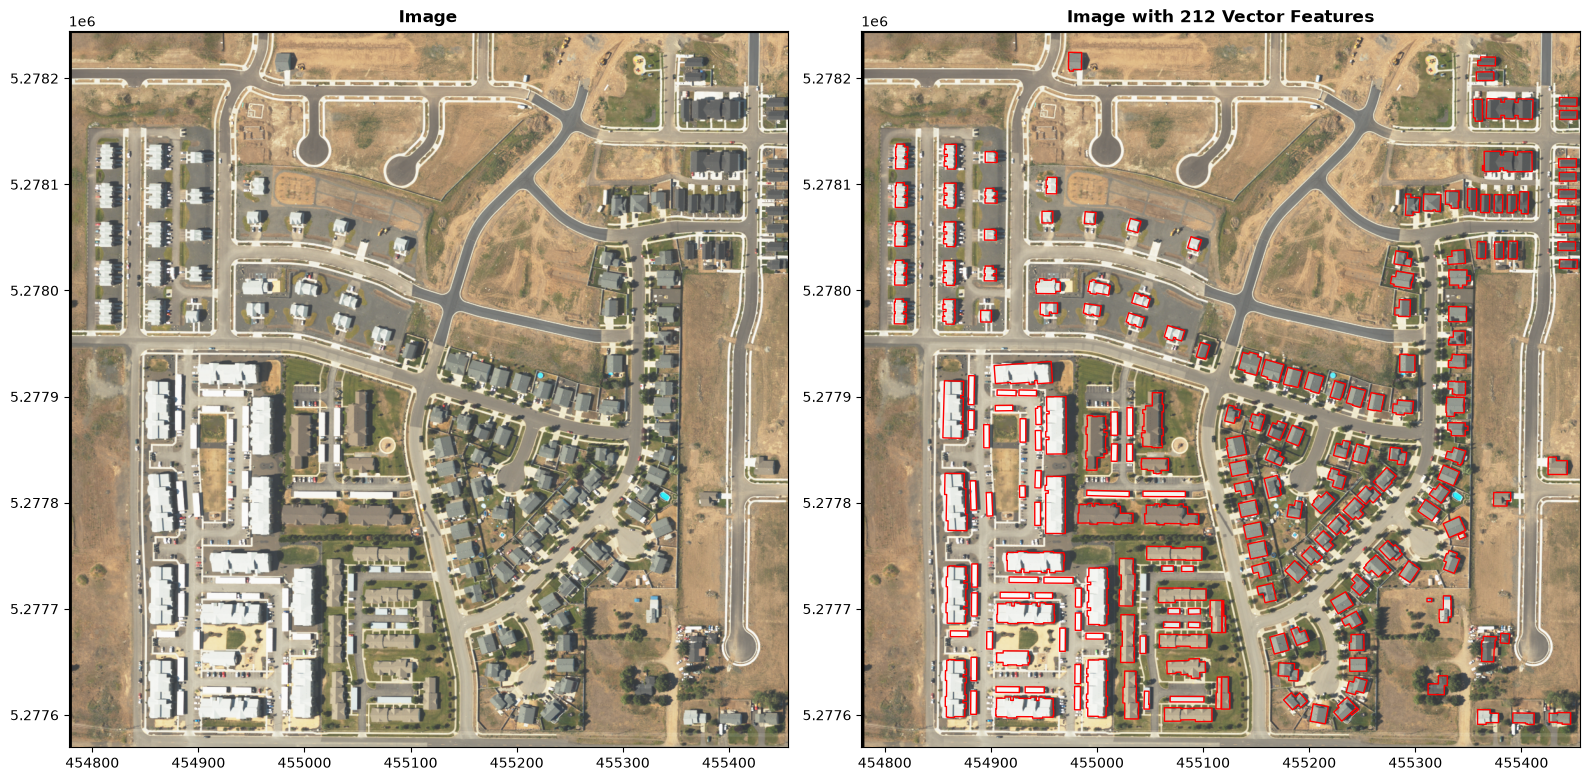

Number of buildings: 212


In [2]:
image_path = f"{data_dir}/images/naip_rgb_train_tile1.tif"
mask_path = f"{data_dir}/masks2/naip_rgb_train_tile1.geojson"

fig, axes, info = geoai.display_image_with_vector(image_path, mask_path)
print(f"Number of buildings: {info['num_features']}")

### D. Method 1: single file for all images

The function loads the vector file once, spatially filters features for each image based on that image's bounds, and, with `skip_empty_tiles=True`, only keeps tiles that actually contain a feature.

In [4]:
stats = geoai.export_geotiff_tiles_batch(
    images_folder=f"{data_dir}/images",
    masks_file=f"{data_dir}/masks1/naip_train_buildings.geojson",
    output_folder="output/method1_single_mask",
    tile_size=256,
    stride=128,
    class_value_field="class",
    skip_empty_tiles=True,
    quiet=False,
)
print(f"Images processed: {stats['processed_pairs']}")
print(f"Total tiles generated: {stats['total_tiles']}")
print(f"Tiles with features: {stats['tiles_with_features']}")

Processing image pairs:   0%|          | 0/2 [00:00<?, ?it/s]

Images processed: 2
Total tiles generated: 141
Tiles with features: 141


This method is efficient, but only if the shared annotation file really overlaps all images. If the feature count is unexpectedly low for some images, check whether the annotation extent is smaller than the image coverage.

### E. Method 2: matched by sorted order

This pairs the first image in the folder with the first mask file, the second with the second, and so on, based purely on alphabetical order. It works here because `naip_rgb_train_tile1.tif` and `naip_rgb_train_tile1.geojson` both sort first, but that alignment is a property of the filenames, not something the function checks for you.

Before using sorted-order matching, print the implied pairs.

In [5]:
image_files = sorted(os.listdir(f"{data_dir}/images"))
annotation_files = sorted(os.listdir(f"{data_dir}/masks2"))

for image_file, annotation_file in zip(image_files, annotation_files):
    print(image_file, "→", annotation_file)

naip_rgb_train_tile1.tif → naip_rgb_train_tile1.geojson
naip_rgb_train_tile2.tif → naip_rgb_train_tile2.geojson


Continue only if all pairs clearly belong together.

In [6]:
stats = geoai.export_geotiff_tiles_batch(
    images_folder=f"{data_dir}/images",
    masks_folder=f"{data_dir}/masks2",
    output_folder="output/method2_sorted_order",
    tile_size=256,
    stride=128,
    class_value_field="class",
    skip_empty_tiles=True,
    match_by_name=False,
)
print(f"Images processed: {stats['processed_pairs']}")
print(f"Total tiles generated: {stats['total_tiles']}")
print(f"Tiles with features: {stats['tiles_with_features']}")

Processing image pairs:   0%|          | 0/2 [00:00<?, ?it/s]

Images processed: 2
Total tiles generated: 141
Tiles with features: 141


```{admonition} Compare method 2 and method 3 on purpose
:class: hint
Method 2 and method 3 below use the exact same input folders. Running both and comparing `stats['processed_pairs']` is a good way to convince yourself that sorted-order and filename matching can silently diverge once file naming gets messier than this tidy example.
```

### F. Method 3: matched by filename

When each image has its own annotation file sharing the same base name, `match_by_name=True` is the most reliable pairing option, since it does not depend on file ordering at all.

In [7]:
stats = geoai.export_geotiff_tiles_batch(
    images_folder=f"{data_dir}/images",
    masks_folder=f"{data_dir}/masks2",
    output_folder="output/method3_matched_name",
    tile_size=256,
    stride=128,
    class_value_field="class",
    skip_empty_tiles=True,
    match_by_name=True,
)
print(f"Images processed: {stats['processed_pairs']}")
print(f"Total tiles generated: {stats['total_tiles']}")
print(f"Tiles with features: {stats['tiles_with_features']}")

Processing image pairs:   0%|          | 0/2 [00:00<?, ?it/s]

Images processed: 2
Total tiles generated: 141
Tiles with features: 141


This is usually the safest pairing mode for project datasets because `naip_rgb_train_tile1.tif` is paired with `naip_rgb_train_tile1.geojson`, not merely with the first file in a sorted list.

### G. Working with raster masks

Some projects already have labels as raster masks, for example land-cover classification maps. In that case, you can pass a folder of raster masks directly instead of vector files. The function pairs images and masks the same way, just without the vector-to-raster conversion step.

In [8]:
url = "https://data.source.coop/opengeos/geoai/landcover-sample-data.zip"
data_dir2 = geoai.download_file(url, output_path=str(DATA_DIR / Path(url).name))

result = geoai.export_geotiff_tiles_batch(
    images_folder=f"{data_dir2}/images",
    masks_folder=f"{data_dir2}/masks",
    output_folder=f"{data_dir2}/tiles",
    tile_size=512,
    stride=384,
    quiet=True,
)

This skips the vector-to-raster conversion step. The key check is still the same: each image tile must have a corresponding mask tile with the same spatial extent and grid alignment.

The output folder gets the same `images/` and `masks/` structure as before, just built from raster labels instead of vector ones.

### H. Advanced usage

`export_geotiff_tiles_batch()` accepts the same fine-grained parameters you met on the [vector-to-raster page](03_vector-to-raster-masks.md) and the [tiling page](04_tiling-and-image-chips.md), buffer radius, all-touched, tile size, and stride, plus a `max_tiles` limit that is useful for a quick test run before committing to a full batch.

In [9]:
stats = geoai.export_geotiff_tiles_batch(
    images_folder=f"{data_dir}/images",
    masks_file=f"{data_dir}/masks1/naip_train_buildings.geojson",
    output_folder="output/advanced_example",
    tile_size=512,
    stride=256,
    class_value_field="class",
    buffer_radius=0.5,
    skip_empty_tiles=True,
    all_touched=True,
    max_tiles=10,
    quiet=False,
)
print(f"Generated {stats['total_tiles']} tiles with 50% overlap")

Processing image pairs:   0%|          | 0/2 [00:00<?, ?it/s]

Generated 20 tiles with 50% overlap


| Parameter | What it changes | When to use carefully |
| --- | --- | --- |
| `tile_size` | Size of each image chip. | Match to model input size and feature size. |
| `stride` | Overlap between neighbouring chips. | Use more overlap when edge objects matter. |
| `buffer_radius` | Expands vector labels before rasterisation. | Only when small spatial misalignments are expected and documented. |
| `all_touched=True` | Includes all pixels touched by a polygon. | Can enlarge masks, especially for small or narrow features. |
| `skip_empty_tiles=True` | Removes chips without labelled features. | Useful for rare objects, but may remove background examples. |
| `max_tiles` | Limits the number of generated tiles. | Useful for testing before a full batch run. |

```{caution}
Parameters such as `buffer_radius` and `all_touched=True` change the label geometry. They may be useful, but they also change what the model learns.
```

### I. Check summary statistics

Every batch run returns a summary dictionary. Use it as a first quality signal before inspecting individual tiles.

In [10]:
print("Images processed:", stats["processed_pairs"])
print("Total tiles generated:", stats["total_tiles"])
print("Tiles with features:", stats["tiles_with_features"])

if stats["total_tiles"] > 0:
    feature_percentage = stats["tiles_with_features"] / stats["total_tiles"] * 100
    print(f"Feature percentage: {feature_percentage:.1f}%")

Images processed: 2
Total tiles generated: 20
Tiles with features: 20
Feature percentage: 100.0%


Watch for suspicious results:

| Result | Possible meaning | First action |
| --- | --- | --- |
| `processed_pairs` is lower than expected | Some images were not paired with labels. | Check filenames, folder paths and pairing mode. |
| `total_tiles` is zero | No valid tiles were generated. | Check image paths, extents, tile size and output folder. |
| `tiles_with_features` is zero | Labels may not overlap images, or class field is wrong. | Inspect bounds and overlay labels on imagery. |
| Feature percentage is unexpectedly high | Empty tiles may have been skipped, or labels may cover too much. | Check `skip_empty_tiles` and inspect masks. |
| Feature percentage is unexpectedly low | Annotations may be incomplete or misaligned. | Preview image-label pairs and check annotation coverage. |

---

### J. Visualise generated tiles

Statistics are useful, but they are not enough. Always inspect image-mask pairs after a batch run.

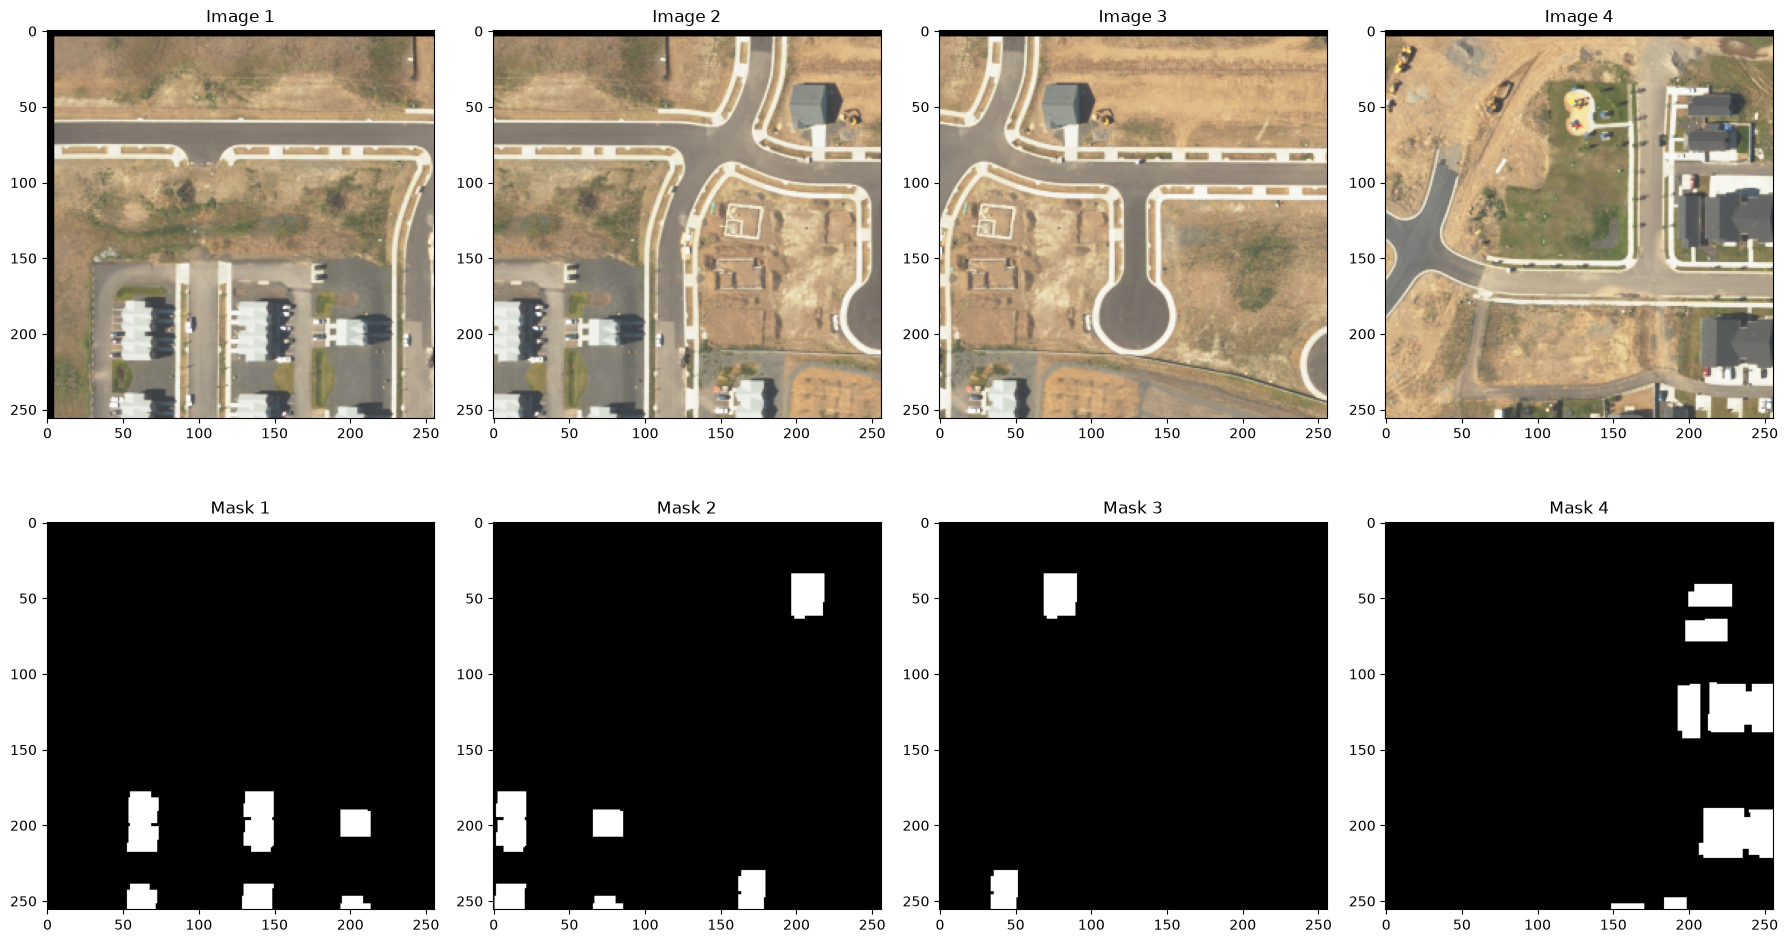

In [11]:
output_dir = "output/method1_single_mask"

fig = geoai.display_training_tiles(
    output_dir=output_dir,
    num_tiles=4,
    figsize=(18, 10),
)

Check whether:

- each image tile has a matching mask tile,
- masks mark the correct visible features,
- labels are not shifted,
- edge objects are handled as expected,
- empty or background-only tiles are not dominating the dataset,
- the output folder structure is clear.

A batch workflow is only successful when the generated tiles are usable for training, not merely when the code finishes without errors.

---

## 4. Common pitfalls

- **Assuming sorted-order pairing is safe without checking the file lists first.** Print both folders' contents and compare them manually before trusting `match_by_name=False`.
- **Not checking the feature percentage after a batch run.** A very low percentage often means the pairing, not the data itself, is the problem.
- **Mixing vector and raster masks in the same batch call without realizing it.** Decide up front which mode your annotations are in, since the function behaves differently for each.

---

## 5. Mini task

If your project involves more than one image, list your image and annotation files and decide which of the three pairing methods fits your naming convention. If your project has only one image so far, describe which method you would use once you add a second one.

:::{note} Sample solution
:class: dropdown

For a project with imagery tiles named `city_north.tif`, `city_south.tif` and annotation files named `city_north.geojson`, `city_south.geojson`, matching by filename (`match_by_name=True`) is the clear choice, since the base names already correspond exactly and this method does not depend on file ordering. Sorted-order matching would happen to work here too, but filename matching is safer if a third tile is added later in a different alphabetical position.
:::

---

## 6. Key takeaways

- `export_geotiff_tiles_batch()` extends single-image tiling to a whole folder, with three ways of pairing images to annotations.
- Matching by filename is the most robust option whenever your file naming supports it; sorted-order matching depends on an assumption that is easy to get wrong silently.
- The function also accepts pre-rasterized mask folders directly, skipping the vector-to-raster step.
- Always check the returned summary statistics, especially the feature percentage, before moving on to visual inspection.

### Useful links

- [GeoAI Video Tutorial](https://youtu.be/RTv-Fz3Y5OE?si=SSeksyX3ZE-1UcYz) - creating image chips from multiple images and masks